# Autoencoders: Basic Principles and Applications

As we said in lecture, autoencoders are trained to copy their inputs to their outputs.
This sounds simple enough, but the twist is that there is a dimensional bottleneck that forces the autoencoder to compress the input data into a reduced dimensional space.
All autoencoders are a encoder-decoder pair, even if the encoder and decoder can both be stacked (a stack of encoder layers, for example).
The *coding* that maps inputs to the reduced space is the real output of the autoencoder training.
The *reconstruction* is the output of the decoder

The autoencoder can be used in the following ways (there are many more):
- dimensionality reduction (feature extraction or data compression)
- ignore noise fluctuations and focus on essential features (denoising)
- use the coding to generate random reconstructions learned from the input data (generative)





# Simple example using fashion MNIST dataset

(This example is from Aurélien Géron's book Hands-On Machine Learning.)



In [1]:
import torch
import torch.nn as nn
import numpy as np

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cuda


In [2]:
stacked_encoder = nn.Sequential(
    nn.Flatten(),
    nn.Linear(1 * 28 * 28, 128), nn.ReLU(),
    nn.Linear(128, 32), nn.ReLU(),
)
stacked_decoder = nn.Sequential(
    nn.Linear(32, 128), nn.ReLU(),
    nn.Linear(128, 1 * 28 * 28), nn.Sigmoid(),
    nn.Unflatten(dim=1, unflattened_size=(1, 28, 28))
)
stacked_autoencoder = nn.Sequential(stacked_encoder, stacked_decoder).to(DEVICE)

I find that it is useful to print out the architecture, just to make sure we understand what has been built.

In [3]:
stacked_autoencoder

Sequential(
  (0): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=32, bias=True)
    (4): ReLU()
  )
  (1): Sequential(
    (0): Linear(in_features=32, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=784, bias=True)
    (3): Sigmoid()
    (4): Unflatten(dim=1, unflattened_size=(1, 28, 28))
  )
)

## Load data from fashion MNIST dataset

The FashionMNIST dataset contains 28x28 pixel images of fashion items. We'll use a split of approximately 90/10 training and validation data.

In [4]:
import torchvision
import torchvision.transforms.v2 as T
from torch.utils.data import DataLoader

toTensor = T.Compose([T.ToImage(), T.ToDtype(torch.float32, scale=True)])

train_and_valid_data = torchvision.datasets.FashionMNIST(
    root="datasets", train=True, download=True, transform=toTensor)
test_data = torchvision.datasets.FashionMNIST(
    root="datasets", train=False, download=True, transform=toTensor)

torch.manual_seed(42)
train_data, valid_data = torch.utils.data.random_split(
    train_and_valid_data, [55_000, 5_000])

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_data, batch_size=32)
test_loader = DataLoader(test_data, batch_size=32)

100%|██████████| 26.4M/26.4M [00:02<00:00, 11.4MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 182kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.38MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 13.7MB/s]


### Visualization of data

An example image is plotted here.

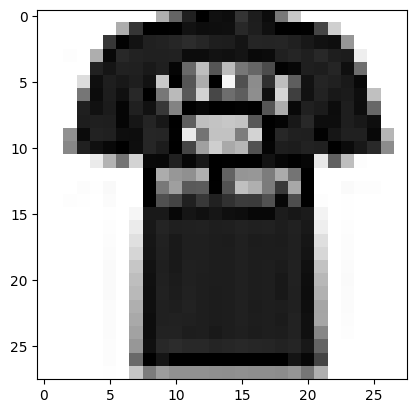

In [5]:
import matplotlib.pyplot as plt

X_sample, y_sample = next(iter(train_loader))
plt.imshow(X_sample[5].permute(1, 2, 0).cpu(), cmap="binary")

### Visualization from untrained autoencoder

We can run the images through the randomly initialized untrained autoencoder.

But don't be suprised if the output does not match the input at all--this is an untrained autoencoder!

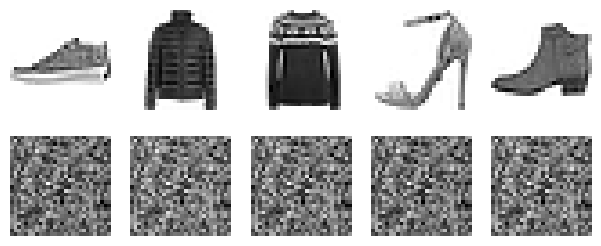

In [6]:
def plot_image(image):
    plt.imshow(image.permute(1, 2, 0).cpu(), cmap="binary")
    plt.axis("off")

def plot_reconstructions(model, images, n_images=5):
    images = images[:n_images]
    with torch.no_grad():
        y_pred = model(images.to(DEVICE))

    fig = plt.figure(figsize=(len(images) * 1.5, 3))
    for idx in range(len(images)):
        plt.subplot(2, len(images), 1 + idx)
        plot_image(images[idx])
        plt.subplot(2, len(images), 1 + len(images) + idx)
        plot_image(y_pred[idx])

X_valid = torch.stack([x for x, _ in valid_data])
plot_reconstructions(stacked_autoencoder, X_valid)
plt.show()

## Train autoencoder

The training proceeds like any other neural network, with one exception: the loss function compares the output prediction to the input vector, not to any label.

In [7]:
def train(model, optimizer, criterion, train_loader, n_epochs):
    model.train()
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", patience=2, factor=0.5)
    for epoch in range(n_epochs):
        total_loss = 0.
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            y_pred = model(X_batch)
            loss = criterion(y_pred, X_batch)
            total_loss += loss.item()
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

        mean_loss = total_loss / len(train_loader)
        print(f"Epoch {epoch + 1}/{n_epochs}, Loss: {mean_loss:.4f}")

In [8]:
optimizer = torch.optim.NAdam(stacked_autoencoder.parameters())
mse = nn.MSELoss()
n_epochs = 5
train(stacked_autoencoder, optimizer, mse, train_loader, n_epochs)

Epoch 1/5, Loss: 0.0238
Epoch 2/5, Loss: 0.0151
Epoch 3/5, Loss: 0.0132
Epoch 4/5, Loss: 0.0122
Epoch 5/5, Loss: 0.0116


### Visualization of trained autoencoder results

The trained autoencoder does a reasonable job of approximating the input images, even though it is limited by its dimensional bottleneck between the encoder and decoder stacks.

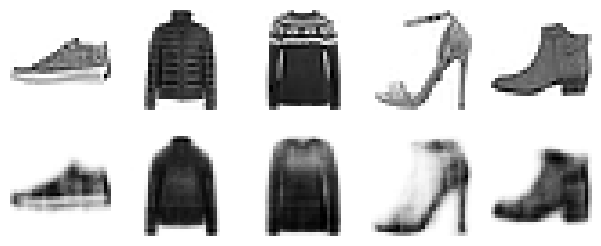

In [9]:
X_valid = torch.stack([x for x, _ in valid_data])
plot_reconstructions(stacked_autoencoder, X_valid)
plt.show()

### Visualization of PCA

Another visualization is the PCA of the encoded images in the latent space. If the autoencoder is learning certain features, it will be able to separate the images based on the most important features.

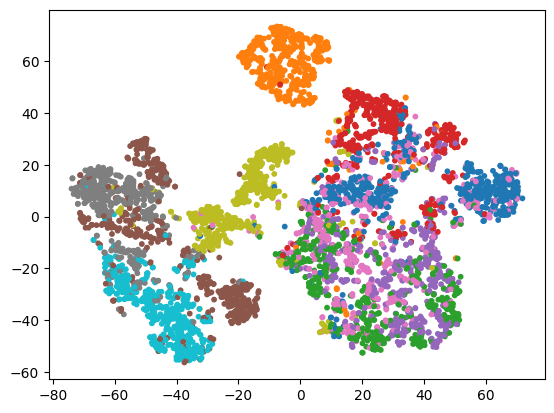

In [10]:
from sklearn.manifold import TSNE

with torch.no_grad():
    # Use only the encoder part to get the compressed representation
    X_valid_compressed = stacked_autoencoder[0](X_valid.to(DEVICE))

tsne = TSNE(init="pca", learning_rate="auto", random_state=42)
X_valid_2D = tsne.fit_transform(X_valid_compressed.cpu())

# Extract labels from valid_data and convert to tensors
y_valid = torch.stack([torch.tensor(y) for x, y in valid_data])
plt.scatter(X_valid_2D[:, 0], X_valid_2D[:, 1], c=y_valid, s=10, cmap="tab10")
plt.show()

Add graphical labels to the plot so that we can make sense of the clusters.

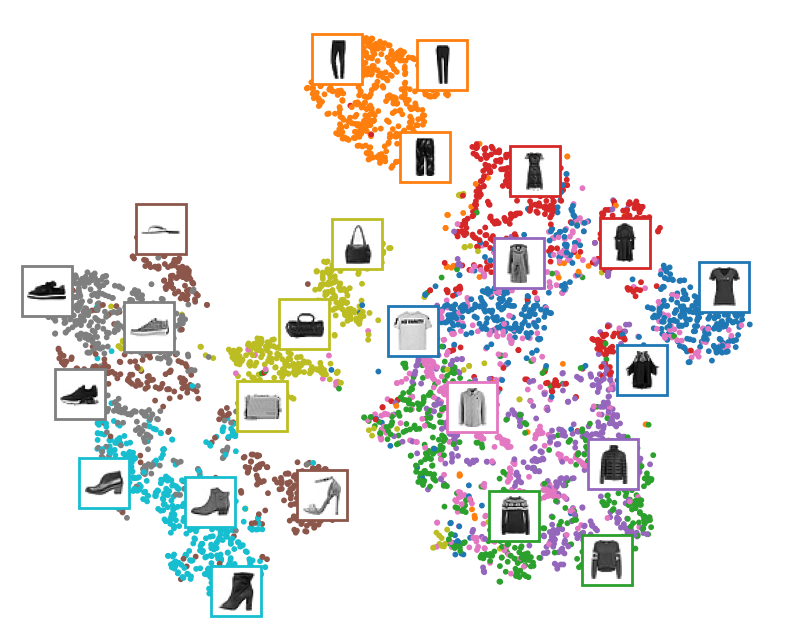

In [11]:
import matplotlib as mpl

plt.figure(figsize=(10, 8))
cmap = plt.cm.tab10
Z = X_valid_2D
Z = (Z - Z.min()) / (Z.max() - Z.min())  # normalize to the 0-1 range
plt.scatter(Z[:, 0], Z[:, 1], c=y_valid, s=10, cmap=cmap)
image_positions = np.array([[1., 1.]])
for index, position in enumerate(Z):
    dist = ((position - image_positions) ** 2).sum(axis=1)
    if dist.min() > 0.02: # if far enough from other images
        image_positions = np.r_[image_positions, [position]]
        imagebox = mpl.offsetbox.AnnotationBbox(
            mpl.offsetbox.OffsetImage(X_valid[index].squeeze(dim=0),
                                      cmap="binary"),
            position, bboxprops={"edgecolor": cmap(y_valid[index]), "lw": 2})
        plt.gca().add_artist(imagebox)

plt.axis("off")

plt.show()

This is amazing! The autoencoder learns that the footwear images belong together, and the jacket images belong together.

Of course the autoencoder is really learning general shapes, and it just happens that all of the footwear has the same triangular shape while the jackets are all rectangles.

## Dropout autoencoder

If the autoencoder is learning general shapes, it doesn't need to depend on each individual pixel for matching. We can even drop out 50% of the pixels for each training set and still learn the images.

In the architecture below, we dropout 50% of the pixels before they even make it into the first layer of the encoder. Keep in mind that the 50% of pixels are randomly dropped, so on average each pixel makes it into 50% of the training.

In [12]:
dropout_encoder = nn.Sequential(
    nn.Flatten(),
    nn.Dropout(0.5),
    nn.Linear(1 * 28 * 28, 128), nn.ReLU(),
    nn.Linear(128, 32), nn.ReLU(),
)
dropout_decoder = nn.Sequential(
    nn.Linear(32, 128), nn.ReLU(),
    nn.Linear(128, 1 * 28 * 28), nn.Sigmoid(),
    nn.Unflatten(dim=1, unflattened_size=(1, 28, 28))
)
dropout_autoencoder = nn.Sequential(dropout_encoder, dropout_decoder).to(DEVICE)

optimizer = torch.optim.NAdam(dropout_autoencoder.parameters())
mse = nn.MSELoss()
n_epochs = 5
train(dropout_autoencoder, optimizer, mse, train_loader, n_epochs)

Epoch 1/5, Loss: 0.0261
Epoch 2/5, Loss: 0.0187
Epoch 3/5, Loss: 0.0174
Epoch 4/5, Loss: 0.0167
Epoch 5/5, Loss: 0.0163


### Visualization of output

This function processes a few validation images through the autoencoder and displays the original images and their reconstructions.
The reconstruction is worse than before because of the drop out but still not too bad.
Could we drop out even more pixels and still get a decent result? Try it!

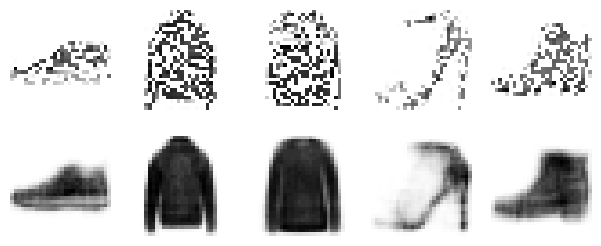

In [13]:
torch.manual_seed(42)
dropout = nn.Dropout(0.5)
plot_reconstructions(dropout_autoencoder, dropout(X_valid))

plt.show()

## Denoising autoencoder

By adding Gaussian noise to the autoencoder training inputs, we can teach the autoencoder to ignore the noise and recover the image.

Here are add Gaussian noise pixel-by-pixel to the underlying image.

In [14]:
class GaussianNoise(nn.Module):
    def __init__(self, std):
        super().__init__()
        self.std = std

    def forward(self, X):
        if self.training:  # only add noise during training
            noise = torch.randn_like(X) * self.std
            return X + noise
        return X

In [15]:
noise_encoder = nn.Sequential(
    nn.Flatten(),
    GaussianNoise(0.5),
    nn.Linear(1 * 28 * 28, 128), nn.ReLU(),
    nn.Linear(128, 128), nn.ReLU(),
)
noise_decoder = nn.Sequential(
    nn.Linear(128, 128), nn.ReLU(),
    nn.Linear(128, 1 * 28 * 28), nn.Sigmoid(),
    nn.Unflatten(dim=1, unflattened_size=(1, 28, 28))
)
noise_autoencoder = nn.Sequential(noise_encoder, noise_decoder).to(DEVICE)

In [16]:
optimizer = torch.optim.NAdam(noise_autoencoder.parameters(), lr=0.01)
train(noise_autoencoder, optimizer, mse, train_loader, n_epochs=5)

Epoch 1/5, Loss: 0.0291
Epoch 2/5, Loss: 0.0239
Epoch 3/5, Loss: 0.0236
Epoch 4/5, Loss: 0.0236
Epoch 5/5, Loss: 0.0236


### Visualization of results

Now if we add Gaussian noise to the test dataset, the autoencoder will denoise the input image and return the denoised fashion image.

How large can you make the Gaussian noise before the autoencoder fails to reconstruct the image?

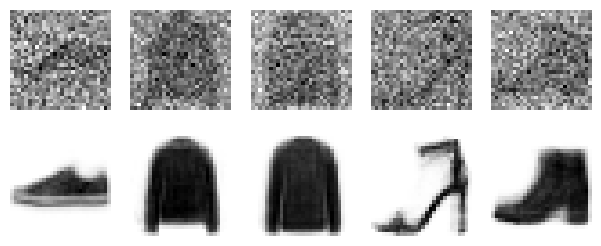

In [17]:
noise = GaussianNoise(0.5)
plot_reconstructions(noise_autoencoder, noise(X_valid))
plt.show()